In [1]:
import json
import numpy as np
from qd.config import PRECOMPILED_EMBEDDINGS_PATH
_dataset_path = PRECOMPILED_EMBEDDINGS_PATH
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

NS_PATH = "data/ns/"

ns_elites_path = NS_PATH + "elites.json"

with open(ns_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))
print("Elite keys:", elites[0].keys())

Number of elites: 248
Elite keys: dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells', 'trackSize', 'fitness', 'embedding', 'archiveIndex'])


Speed metric has 0 zeros out of 4979417 values.
Steering metric has 2376 zeros out of 4979417 values.
Distance from side metric has 0 zeros out of 4979417 values.
[ 6.48648e+01  1.33923e-02  1.36024e+01  6.44346e+01  1.25898e-02
  1.45230e+01  6.12907e+01  1.66727e-02  1.52328e+01  5.88738e+01
  1.16239e-02  1.57138e+01  5.63204e+01  9.90176e-03  1.59846e+01
  5.33297e+01  2.91854e-02  1.58849e+01  5.05997e+01  6.01993e-02
  1.50476e+01  4.80661e+01  7.13042e-02  1.38793e+01  4.53817e+01
  5.94559e-02  1.27933e+01  4.22669e+01  1.02398e-01  1.19783e+01
  3.93941e+01  1.36476e-01  1.08838e+01  3.67537e+01  9.13402e-02
  9.36253e+00  3.41676e+01  4.60505e-02  7.55041e+00  3.17199e+01
  5.13559e-02  5.56259e+00  2.98514e+01  8.20393e-02  3.61915e+00
  2.78984e+01  1.40707e-01  2.07293e+00  2.66778e+01  1.34022e-01
  1.39994e+00  2.57959e+01  1.36723e-01  1.25452e+00  2.48884e+01
  1.44432e-01  1.26951e+00  2.43360e+01  1.48668e-01  1.29597e+00
  2.38404e+01  1.63736e-01  1.28703e+00  2.31

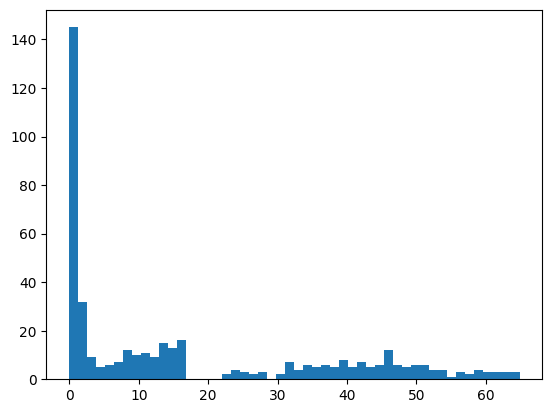

In [2]:
# load dataset at : qd\embeddings\datasets\dataset20k_metrics_mixedRng_tita.npz
import matplotlib.pyplot as plt

dataset = np.load("qd/embeddings/datasets/dataset20k_metrics_mixedRng_tita.npz")
flat_metrics = dataset["data"]
indices = dataset["indices"]
ids = dataset["ids"]

flat_metrics = np.delete(flat_metrics, [0,3,4,5], axis=1)

# get separate metrics based on indices in order speed steering dist_from_side
speed_metrics = flat_metrics[:, 0]
steering_metrics = flat_metrics[:, 1]
dist_from_side_metrics = flat_metrics[:, 2]

# count the 0s in each metric
speed_zero_count = sum(1 for x in speed_metrics if x == 0)
steering_zero_count = sum(1 for x in steering_metrics if x == 0)
dist_from_side_zero_count = sum(1 for x in dist_from_side_metrics if x == 0)

print(f"Speed metric has {speed_zero_count} zeros out of {len(speed_metrics)} values.")
print(f"Steering metric has {steering_zero_count} zeros out of {len(steering_metrics)} values.")
print(f"Distance from side metric has {dist_from_side_zero_count} zeros out of {len(dist_from_side_metrics)} values.")

metrics = np.split(flat_metrics, indices)

# pick a 10 random metrics and print the 0 percentage for each of them
for i in range(1):
    metric = metrics[i]
    flattened_metric = metric.flatten()
    print(flattened_metric)
    #plot number distribution of values in the metric
    plt.hist(flattened_metric, bins=50)
    plt.show()


In [3]:
import sys
from qd.qd_runner import QDRunner
import qd.emitter as emitter_module
import qd.utils as utils_module
import qd.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'qd.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = NS_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
stats = state["stats"]

print("stats keys:", stats[0].keys())
grid_state = stats[-1]["grid_state"]
print("grid_state keys:", grid_state[-1].keys())

# sort grid_state by sub_count highest to lowest
grid_state_sorted = sorted(grid_state, key=lambda x: x["sub_count"], reverse=True)

print(grid_state_sorted[0]["elite"].keys())


2026-05-15 11:03:04 [info     ] Checkpoint loaded              path=data/ns/checkpoints\checkpoint_0999.pkl resume_iter=1000
stats keys: dict_keys(['iteration', 'initial_WSS', 'Archive size', 'iteration_best', 'global_best_score', 'global_best_id', 'new_elites', 'substituted_elites', 'wss', 'qd_score', 'acceptance_rate', 'mean_pairwise_dist', 'high_quality_coverage', 'mean_knn_novelty', 'fitness_novelty_corr', 'grid_state'])
grid_state keys: dict_keys(['elite', 'sub_count', 'new', 'fitness'])
dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells'])


In [4]:
import umap
import os
import matplotlib.pyplot as plt
import numpy as np
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = _embeddings
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")


Loaded precomputed embeddings with shape: (19183, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=-4.658318042755127, max=3.6783337593078613
y: min=4.823168754577637, max=11.07054328918457


Elite ID 252.8176025450281 UMAP 2D coords: [-2.9320672 10.92563  ]
Elite ID 884.4117150500359 UMAP 2D coords: [-3.2890902  6.1218796]
Elite ID 688.9232355734215 UMAP 2D coords: [-3.751069  6.316891]


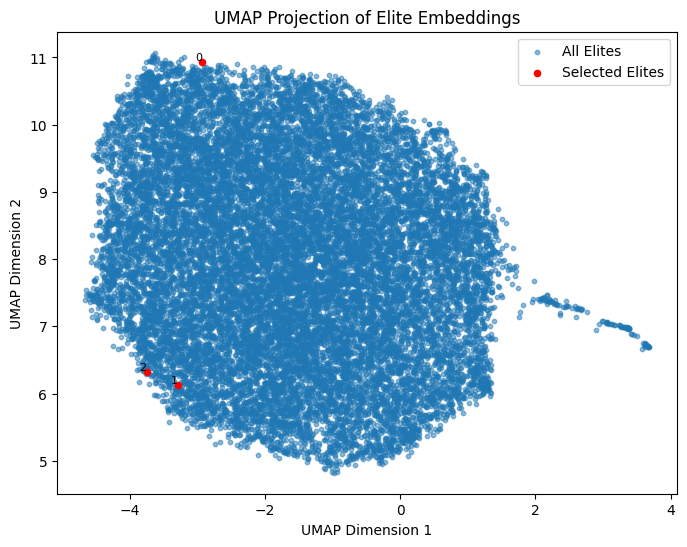

In [5]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
selected_elite_ids = [252.8176025450281, 884.4117150500359, 688.9232355734215]


# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in selected_elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

reduced_points = []
for elite in selected_elites:
    embedding = elite["embedding"]
    point = umap_model.transform([embedding])[0]
    print(f"Elite ID {elite['id']} UMAP 2D coords: {point}")
    reduced_points.append(point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            s=10, alpha=0.5, label="All Elites")

reduced_points = np.array(reduced_points)
plt.scatter(reduced_points[:, 0], reduced_points[:, 1],
            s=20, color="red", label="Selected Elites")

# Add numbering based on order in elite_ids
for i, (x, y) in enumerate(reduced_points):
    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom', color='black')

plt.title("UMAP Projection of Elite Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

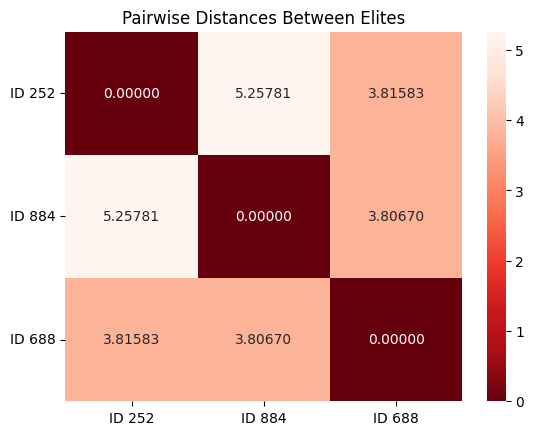

In [6]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {int(id)}" for id in selected_elite_ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".5f")
plt.title("Pairwise Distances Between Elites")
plt.yticks(rotation=0)
plt.show()

Elite ID: 252.8176025450281
Distances: [4.50045194 5.10442669 5.16764698 5.50015351 5.92536443 5.98093855
 6.01276095 6.06622924 6.15882003 6.21198003 6.21786875 6.29773884
 6.34603328 6.3844741  6.39384121 6.44457523 6.58137091 6.59248194
 6.67775936 6.68837995 6.72622709 6.75521713 6.76025975 6.76262177
 6.78511674 6.80849535 6.82274419 6.83290419 6.84678942 6.90927167]
Mean distance to neighbors: 6.30876
---


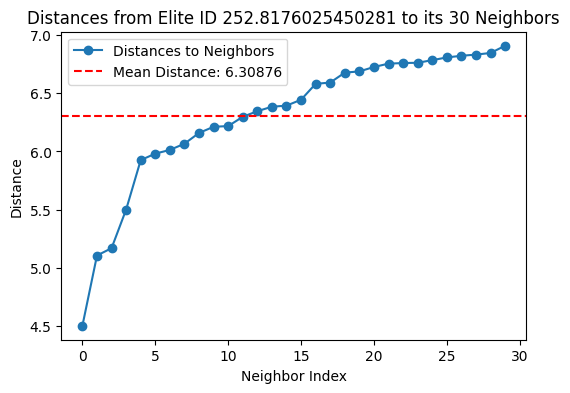

Elite ID: 884.4117150500359
Distances: [2.86998813 5.78031083 6.20543582 6.53489372 6.61645143 6.72823738
 6.80107251 6.91875769 6.95656611 6.97896451 6.9823419  6.9953501
 7.01141666 7.0455975  7.05005353 7.05676565 7.1148     7.14500193
 7.19062246 7.20846419 7.24785911 7.25074687 7.26159972 7.34208598
 7.37578769 7.38729154 7.38849201 7.40099094 7.40301543 7.41681132]
Mean distance to neighbors: 6.88886
---


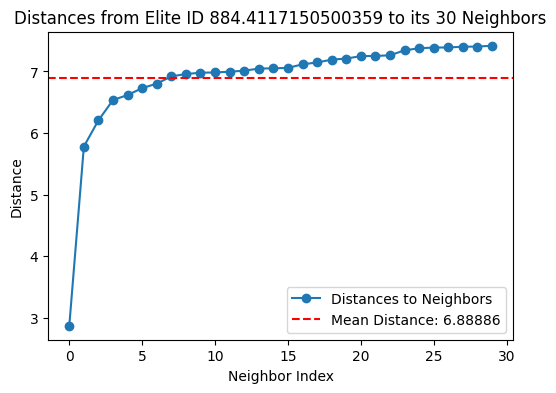

Elite ID: 688.9232355734215
Distances: [3.17392535 5.6790089  5.99069714 6.05922766 6.08357231 6.08587271
 6.15683137 6.25799171 6.33110076 6.37785861 6.4167056  6.50286854
 6.57595932 6.59653839 6.63486741 6.72916113 6.73347101 6.76369501
 6.79543469 6.81177406 6.82489827 6.8622816  6.88206076 6.92592308
 6.94024593 6.9731122  6.99593579 7.02001746 7.03844392 7.07751162]
Mean distance to neighbors: 6.47657
---


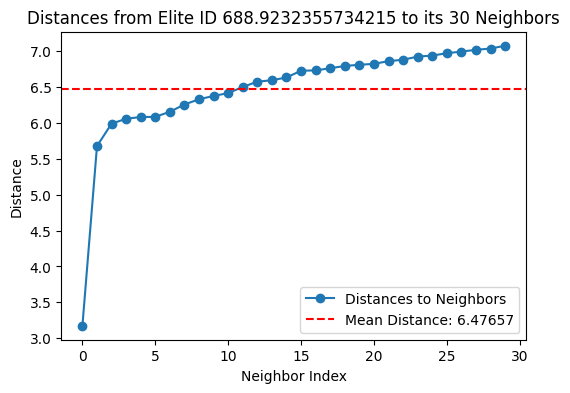

In [7]:
# compute kNeighbors for each elite
from sklearn.neighbors import NearestNeighbors


elites_minus_selected = [elite for elite in elites if elite["id"] not in selected_elite_ids]

elite_embeddings = [elite["embedding"] for elite in elites_minus_selected]

n_neighbors = 30
knn = NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(elite_embeddings)

for i, elite in enumerate(selected_elites):
    elite_id = elite["id"]
    elite_embedding = elite["embedding"]
    distances, indices = knn.kneighbors([elite_embedding])
    mean_distance = np.mean(distances)
    print(f"Elite ID: {elite_id}")
    print(f"Distances: {distances[0]}")
    print(f"Mean distance to neighbors: {mean_distance:.5f}")
    print("---")
    # plot distances and mean distance
    plt.figure(figsize=(6, 4))
    plt.plot(distances[0], marker='o', label='Distances to Neighbors')
    plt.axhline(mean_distance, color='red', linestyle='--', label=f'Mean Distance: {mean_distance:.5f}')
    plt.title(f"Distances from Elite ID {elite_id} to its {n_neighbors} Neighbors")
    plt.xlabel("Neighbor Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()
    
    
